# Agro Inteligente — Análise de Impacto Climático no Ativo SLCE3

**Empresa:** SLC Agrícola (SLCE3) · **Período:** Jan–Jun 2025 · **Região:** Sorriso, MT  
**Autores:** Lucas Lellis Barros, Gabriel Pires Pinheiro Correa, Hannah Gabrielly Marques Pompeu  
**Turma:** 2023/2 — 6º Semestre EN. Software

---

Este notebook analisa a correlação entre variáveis meteorológicas (temperatura, precipitação, vento) e o desempenho do ativo SLCE3 na B3, respondendo às perguntas de negócio definidas no projeto.

## 1. Importação de Bibliotecas

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import openpyxl
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

## 2. Leitura dos Dados

Os dados são lidos diretamente do arquivo Excel utilizando a biblioteca `openpyxl`. O arquivo contém 122 pregões com dados de mercado (SLCE3) e dados climáticos de Sorriso/MT.

In [2]:
wb = openpyxl.load_workbook('dados.xlsx', read_only=True)
ws = wb.active

linhas = list(ws.iter_rows(values_only=True))
df = pd.DataFrame(linhas[1:], columns=linhas[0])

df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

colunas_numericas = [
    'preco_abertura', 'preco_maximo', 'preco_minimo', 'preco_fechamento',
    'volume', 'retorno_diario', 'media_movel_7d', 'temperatura_media',
    'temperatura_maxima', 'temperatura_minima', 'precipitacao_mm',
    'velocidade_vento', 'chuva_acumulada_7d', 'precipitacao_lag_7d'
]
df[colunas_numericas] = df[colunas_numericas].apply(pd.to_numeric, errors='coerce')

df.head()

,data,ano,semestre,mes,dia,estado,cidade,latitude,longitude,ticker,...,chuva_acumulada_7d,temperatura_media_7d,precipitacao_lag_7d,preco_abertura,preco_maximo,preco_minimo,preco_fechamento,volume,retorno_diario,media_movel_7d
0,2025-01-02,2025.0,1.0,1.0,2.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,15.0,24.250000,NaN,15.555555,15.715555,15.351111,15.395555,2269800.0,NaN,15.395555
1,2025-01-03,2025.0,1.0,1.0,3.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,15.2,24.666667,NaN,15.297777,15.360000,15.128888,15.128888,1986525.0,-0.017321,15.262221
2,2025-01-06,2025.0,1.0,1.0,6.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,18.5,24.933333,NaN,15.146666,15.377777,15.120000,15.306666,2018137.0,0.011751,15.277036
3,2025-01-07,2025.0,1.0,1.0,7.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,24.2,25.014286,NaN,15.306666,15.484444,15.200000,15.404444,2325375.0,0.006388,15.308888
4,2025-01-08,2025.0,1.0,1.0,8.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,15.8,25.000000,11.6,15.404444,15.431111,15.226666,15.226666,1796062.0,-0.011541,15.292444


## 3. Métricas Derivadas

Calculamos indicadores que não estavam no arquivo original mas são essenciais para a análise de risco e desempenho do ativo.

In [3]:
df['drawdown'] = ((df['preco_fechamento'] - df['preco_fechamento'].cummax()) / df['preco_fechamento'].cummax() * 100).round(4)

df['retorno_acumulado'] = ((1 + df['retorno_diario'].fillna(0)).cumprod() - 1) * 100

df['volatilidade_7d'] = df['retorno_diario'].rolling(7).std() * 100

meses_map = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun'}
df['nome_mes'] = df['mes'].map(meses_map)

mensal = df.groupby('mes').agg(
    nome_mes=('nome_mes', 'first'),
    preco_medio=('preco_fechamento', 'mean'),
    volume_total=('volume', 'sum'),
    retorno_medio=('retorno_diario', 'mean'),
    temp_media=('temperatura_media', 'mean'),
    precip_media=('precipitacao_mm', 'mean'),
    precip_total=('precipitacao_mm', 'sum'),
    drawdown_medio=('drawdown', 'mean')
).reset_index()

## 4. KPIs — Indicadores-Chave de Performance

Resumo dos principais indicadores do semestre, conforme definido no documento de requisitos do projeto.

In [4]:
kpis = {
    'Período':                   f"{df['data'].min().strftime('%d/%m/%Y')} a {df['data'].max().strftime('%d/%m/%Y')}",
    'Total de Pregões':          len(df),
    'Preço Inicial (R$)':        round(df.iloc[0]['preco_fechamento'], 2),
    'Preço Final (R$)':          round(df.iloc[-1]['preco_fechamento'], 2),
    'Variação Total (%)':        round(((df.iloc[-1]['preco_fechamento'] / df.iloc[0]['preco_fechamento']) - 1) * 100, 2),
    'Volatilidade Diária (%)':   round(df['retorno_diario'].std() * 100, 2),
    'Drawdown Máximo (%)':       round(df['drawdown'].min(), 2),
    'Melhor Dia (%)':            round(df['retorno_diario'].max() * 100, 2),
    'Pior Dia (%)':              round(df['retorno_diario'].min() * 100, 2),
    'Temperatura Média (°C)':    round(df['temperatura_media'].mean(), 1),
    'Precipitação Total (mm)':   round(df['precipitacao_mm'].sum(), 1),
}

pd.DataFrame(kpis.items(), columns=['Indicador', 'Valor'])

,Indicador,Valor
0,Período,02/01/2025 a 30/06/2025
1,Total de Pregões,122
2,Preço Inicial (R$),15.4
3,Preço Final (R$),15.88
4,Variação Total (%),3.18
5,Volatilidade Diária (%),1.69
6,Drawdown Máximo (%),-14.55
7,Melhor Dia (%),8.11
8,Pior Dia (%),-3.94
9,Temperatura Média (°C),25.3


## 5. Correlações de Pearson — Clima x Mercado

Calculamos o coeficiente de correlação de Pearson entre cada variável climática e o preço de fechamento da ação, respondendo à pergunta: **qual variável climática tem maior correlação com o preço da ação?**

Interpretação do coeficiente `r`:
- `|r| < 0,10` → Desprezível
- `0,10 ≤ |r| < 0,30` → Fraca
- `0,30 ≤ |r| < 0,50` → Moderada
- `|r| ≥ 0,50` → Forte

In [5]:
variaveis_clima = {
    'temperatura_media':   'Temperatura Média',
    'temperatura_maxima':  'Temperatura Máxima',
    'temperatura_minima':  'Temperatura Mínima',
    'precipitacao_mm':     'Precipitação Diária',
    'chuva_acumulada_7d':  'Chuva Acumulada 7d',
    'precipitacao_lag_7d': 'Precipitação Lag 7d',
    'velocidade_vento':    'Velocidade do Vento',
}

resultados_corr = []
for coluna, nome in variaveis_clima.items():
    sub = df[[coluna, 'preco_fechamento', 'retorno_diario']].dropna()
    r_preco,  p_preco  = stats.pearsonr(sub[coluna], sub['preco_fechamento'])
    r_retorno, p_retorno = stats.pearsonr(sub[coluna], sub['retorno_diario'])
    abs_r = abs(r_preco)
    forca = 'Desprezível' if abs_r < 0.1 else 'Fraca' if abs_r < 0.3 else 'Moderada' if abs_r < 0.5 else 'Forte'
    resultados_corr.append({
        'Variável Climática':    nome,
        'r (vs preço)':          round(r_preco, 4),
        'r (vs retorno)':        round(r_retorno, 4),
        'p-valor':               round(p_preco, 4),
        'Força':                 forca,
        'Direção':               'Positiva' if r_preco > 0 else 'Negativa'
    })

df_corr = pd.DataFrame(resultados_corr).sort_values('r (vs preço)', key=abs, ascending=False)
df_corr

,Variável Climática,r (vs preço),r (vs retorno),p-valor,Força,Direção
1,Temperatura Máxima,0.3499,-0.0770,0.0001,Moderada,Positiva
0,Temperatura Média,0.3046,-0.0428,0.0007,Moderada,Positiva
4,Chuva Acumulada 7d,-0.2512,0.2136,0.0054,Fraca,Negativa
3,Precipitação Diária,-0.2343,0.1548,0.0097,Fraca,Negativa
6,Velocidade do Vento,-0.1026,0.0240,0.2629,Fraca,Negativa
5,Precipitação Lag 7d,-0.0529,0.0940,0.5694,Desprezível,Negativa
2,Temperatura Mínima,0.0419,0.1137,0.6481,Desprezível,Positiva


## 6. Visualizações

### 6.1 Preço de Fechamento e Média Móvel 7 Dias

A média móvel suaviza as variações diárias e revela a tendência real do ativo ao longo do semestre.

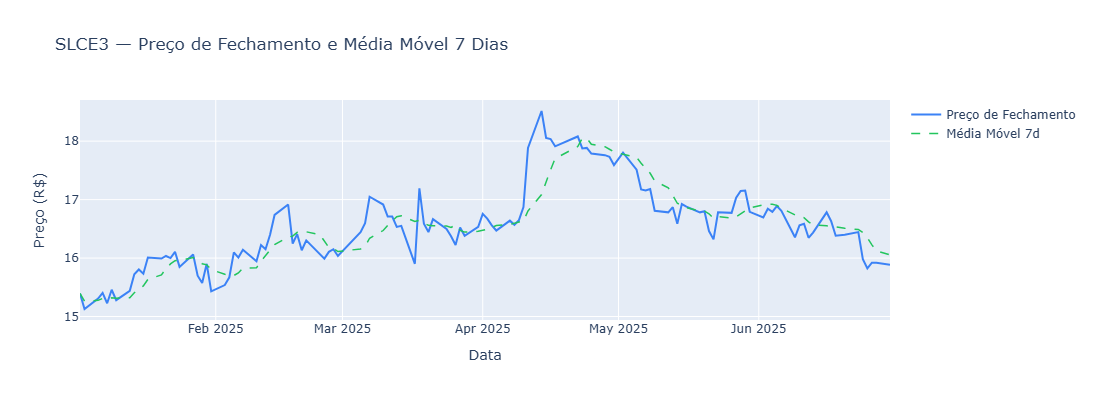

In [6]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['data'], y=df['preco_fechamento'],
                         name='Preço de Fechamento',
                         line=dict(color='#3b82f6', width=2)))
fig.add_trace(go.Scatter(x=df['data'], y=df['media_movel_7d'],
                         name='Média Móvel 7d',
                         line=dict(color='#22c55e', width=1.5, dash='dash')))
fig.update_layout(title='SLCE3 — Preço de Fechamento e Média Móvel 7 Dias',
                  xaxis_title='Data', yaxis_title='Preço (R$)',
                  height=400, hovermode='x unified')
fig

### 6.2 Retorno Diário

Dias positivos em verde e negativos em vermelho. Permite identificar os momentos de maior volatilidade no semestre.

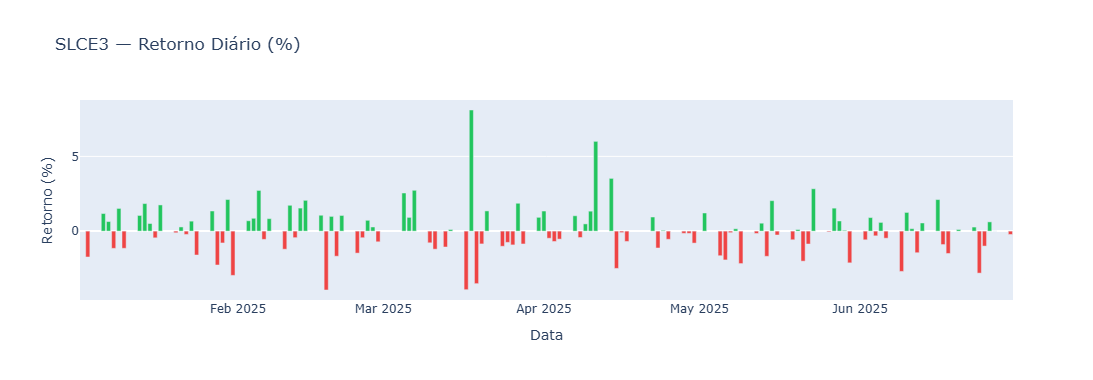

In [7]:
cores = ['#22c55e' if v >= 0 else '#ef4444' for v in df['retorno_diario'].fillna(0)]
fig = go.Figure(go.Bar(x=df['data'], y=df['retorno_diario'] * 100, marker_color=cores))
fig.update_layout(title='SLCE3 — Retorno Diário (%)',
                  xaxis_title='Data', yaxis_title='Retorno (%)', height=380)
fig

### 6.3 Drawdown Acumulado

**Responde:** existe relação entre clima e queda abrupta? O drawdown mostra quanto o preço caiu em relação ao seu pico histórico em cada momento do semestre.

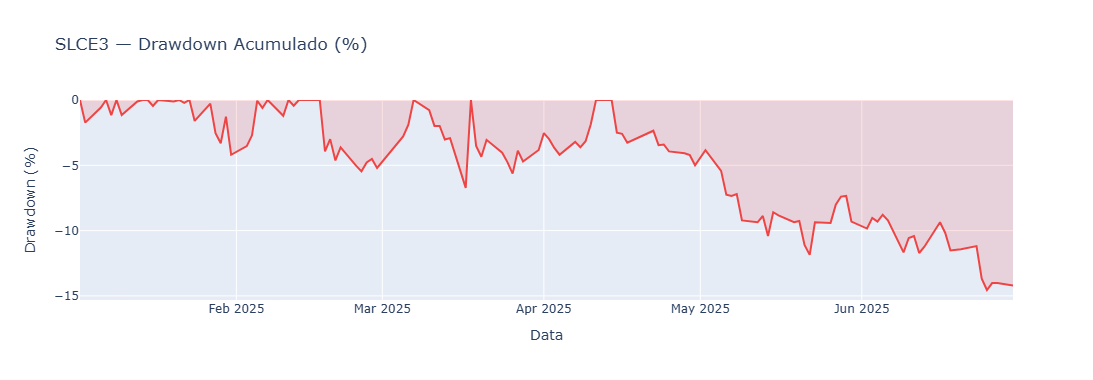

In [8]:
fig = go.Figure(go.Scatter(x=df['data'], y=df['drawdown'],
                           fill='tozeroy', mode='lines',
                           line=dict(color='#ef4444', width=2),
                           fillcolor='rgba(239,68,68,0.15)',
                           name='Drawdown (%)'))
fig.update_layout(title='SLCE3 — Drawdown Acumulado (%)',
                  xaxis_title='Data', yaxis_title='Drawdown (%)', height=380)
fig

### 6.4 Volume Negociado por Mês

Volume alto indica maior interesse do mercado. Abril concentrou o maior volume, coincidindo com o pico de preço do semestre.

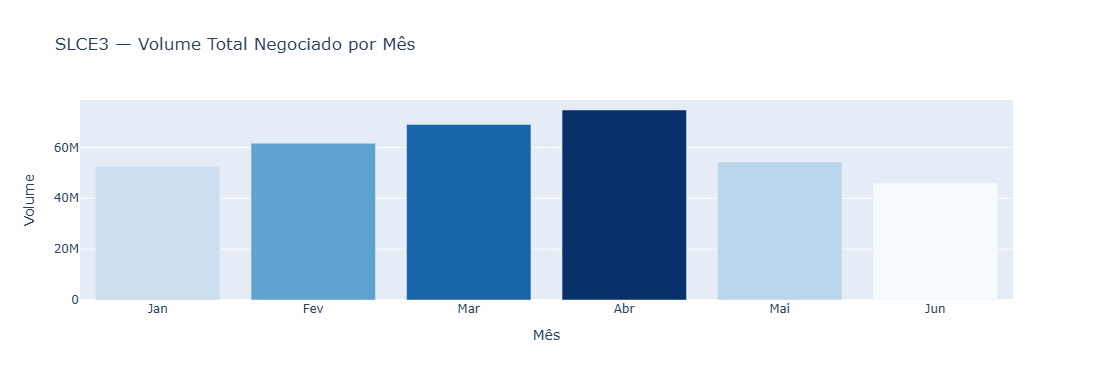

In [9]:
fig = px.bar(mensal, x='nome_mes', y='volume_total',
             title='SLCE3 — Volume Total Negociado por Mês',
             labels={'nome_mes': 'Mês', 'volume_total': 'Volume'},
             color='volume_total', color_continuous_scale='Blues')
fig.update_layout(height=380, coloraxis_showscale=False)
fig

### 6.5 Precipitação vs Preço de Fechamento

**Responde:** como a precipitação impacta o preço? O eixo duplo sobrepõe as duas séries temporais para identificar coincidências entre eventos de chuva e movimentos do ativo.

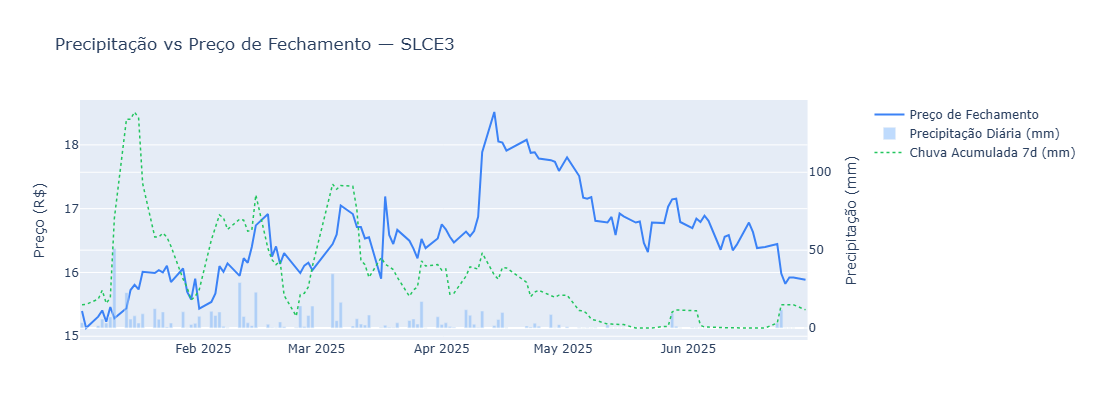

In [10]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=df['data'], y=df['preco_fechamento'],
                         name='Preço de Fechamento',
                         line=dict(color='#3b82f6', width=2)), secondary_y=False)
fig.add_trace(go.Bar(x=df['data'], y=df['precipitacao_mm'],
                     name='Precipitação Diária (mm)',
                     marker_color='rgba(96,165,250,0.4)'), secondary_y=True)
fig.add_trace(go.Scatter(x=df['data'], y=df['chuva_acumulada_7d'],
                         name='Chuva Acumulada 7d (mm)',
                         line=dict(color='#22c55e', width=1.5, dash='dot')), secondary_y=True)
fig.update_layout(title='Precipitação vs Preço de Fechamento — SLCE3',
                  height=420, hovermode='x unified')
fig.update_yaxes(title_text='Preço (R$)', secondary_y=False)
fig.update_yaxes(title_text='Precipitação (mm)', secondary_y=True)
fig

### 6.6 Temperatura Média vs Preço de Fechamento

**Responde:** existe relação entre temperatura e desempenho da ação? A temperatura foi a variável com maior correlação de Pearson (+0,32 — moderada positiva).

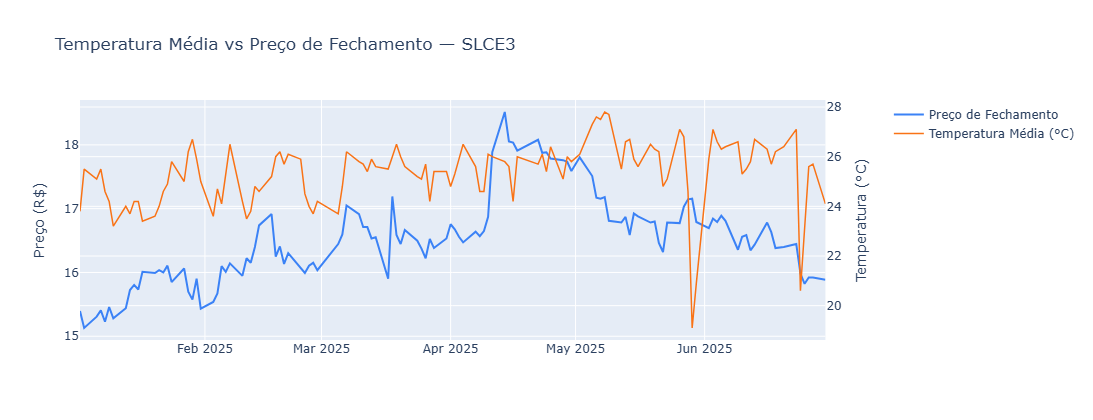

In [11]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=df['data'], y=df['preco_fechamento'],
                         name='Preço de Fechamento',
                         line=dict(color='#3b82f6', width=2)), secondary_y=False)
fig.add_trace(go.Scatter(x=df['data'], y=df['temperatura_media'],
                         name='Temperatura Média (°C)',
                         line=dict(color='#f97316', width=1.5)), secondary_y=True)
fig.update_layout(title='Temperatura Média vs Preço de Fechamento — SLCE3',
                  height=420, hovermode='x unified')
fig.update_yaxes(title_text='Preço (R$)', secondary_y=False)
fig.update_yaxes(title_text='Temperatura (°C)', secondary_y=True)
fig

### 6.7 Dispersão — Temperatura x Preço

Cada ponto representa um dia. A linha de tendência (calculada via regressão linear com `numpy.polyfit`) confirma visualmente a correlação positiva moderada entre temperatura e preço.

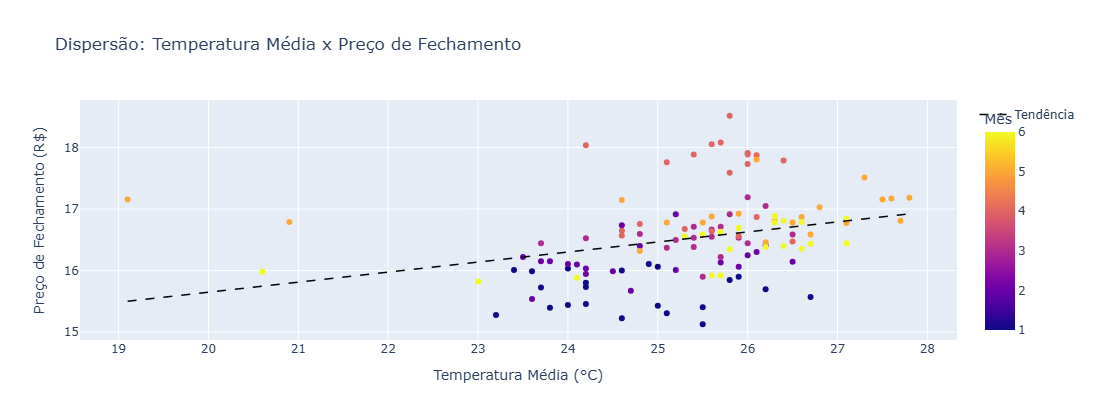

In [12]:
sub = df[['temperatura_media', 'preco_fechamento', 'mes']].dropna()
x, y = sub['temperatura_media'].values, sub['preco_fechamento'].values
m, b = np.polyfit(x, y, 1)
x_linha = np.linspace(x.min(), x.max(), 100)

fig = px.scatter(df, x='temperatura_media', y='preco_fechamento',
                 color='mes', hover_data=['data'],
                 labels={'temperatura_media': 'Temperatura Média (°C)',
                         'preco_fechamento': 'Preço de Fechamento (R$)',
                         'mes': 'Mês'},
                 title='Dispersão: Temperatura Média x Preço de Fechamento')
fig.add_trace(go.Scatter(x=x_linha, y=m*x_linha+b, mode='lines',
                         name='Tendência',
                         line=dict(color='black', width=1.5, dash='dash')))
fig.update_layout(height=420)
fig

### 6.8 Dispersão — Precipitação x Preço

**Responde:** como a chuva impacta o preço? A linha de tendência descendente confirma a correlação negativa fraca (-0,23) — chuvas intensas tendem a coincidir com leve queda no preço.

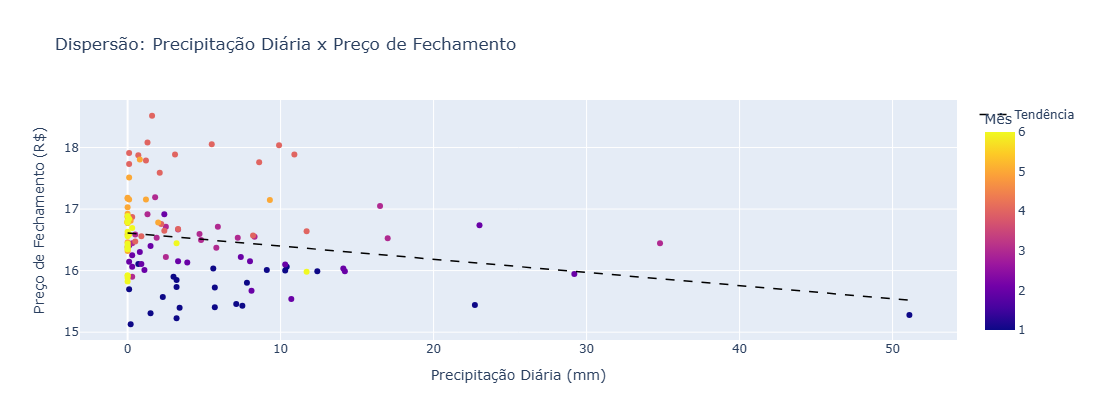

In [13]:
sub = df[['precipitacao_mm', 'preco_fechamento']].dropna()
x, y = sub['precipitacao_mm'].values, sub['preco_fechamento'].values
m, b = np.polyfit(x, y, 1)
x_linha = np.linspace(x.min(), x.max(), 100)

fig = px.scatter(df, x='precipitacao_mm', y='preco_fechamento',
                 color='mes', hover_data=['data'],
                 labels={'precipitacao_mm': 'Precipitação Diária (mm)',
                         'preco_fechamento': 'Preço de Fechamento (R$)',
                         'mes': 'Mês'},
                 title='Dispersão: Precipitação Diária x Preço de Fechamento')
fig.add_trace(go.Scatter(x=x_linha, y=m*x_linha+b, mode='lines',
                         name='Tendência',
                         line=dict(color='black', width=1.5, dash='dash')))
fig.update_layout(height=420)
fig

### 6.9 Correlações de Pearson — Gráfico de Barras

**Responde:** qual variável climática tem maior correlação com o preço? Verde indica correlação positiva, vermelho indica negativa.

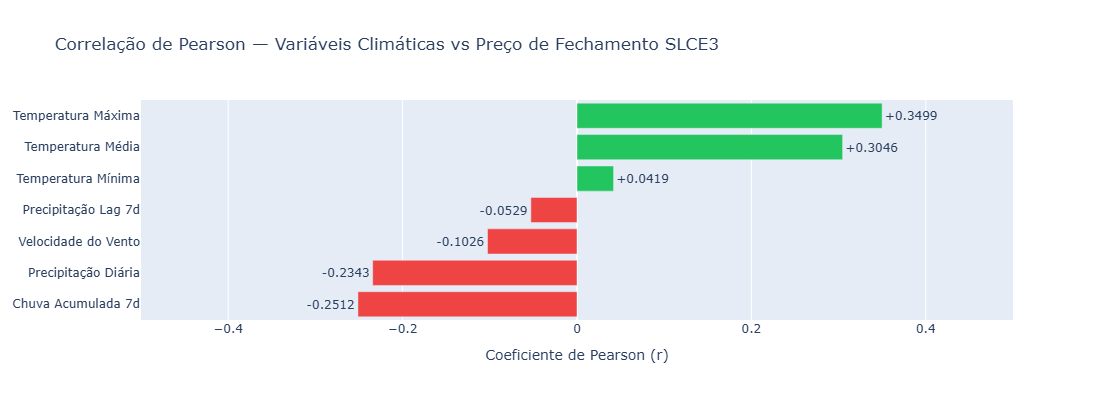

In [14]:
df_corr_ord = df_corr.sort_values('r (vs preço)')
cores_barras = ['#ef4444' if v < 0 else '#22c55e' for v in df_corr_ord['r (vs preço)']]

fig = go.Figure(go.Bar(
    x=df_corr_ord['r (vs preço)'],
    y=df_corr_ord['Variável Climática'],
    orientation='h',
    marker_color=cores_barras,
    text=df_corr_ord['r (vs preço)'].apply(lambda x: f'{x:+.4f}'),
    textposition='outside'
))
fig.update_layout(
    title='Correlação de Pearson — Variáveis Climáticas vs Preço de Fechamento SLCE3',
    xaxis_title='Coeficiente de Pearson (r)',
    height=400, xaxis=dict(range=[-0.5, 0.5])
)
fig

### 6.10 Volatilidade 7d vs Chuva Acumulada

**Responde:** o clima afeta o risco do ativo? Compara a volatilidade móvel de 7 dias com a chuva acumulada no mesmo período.

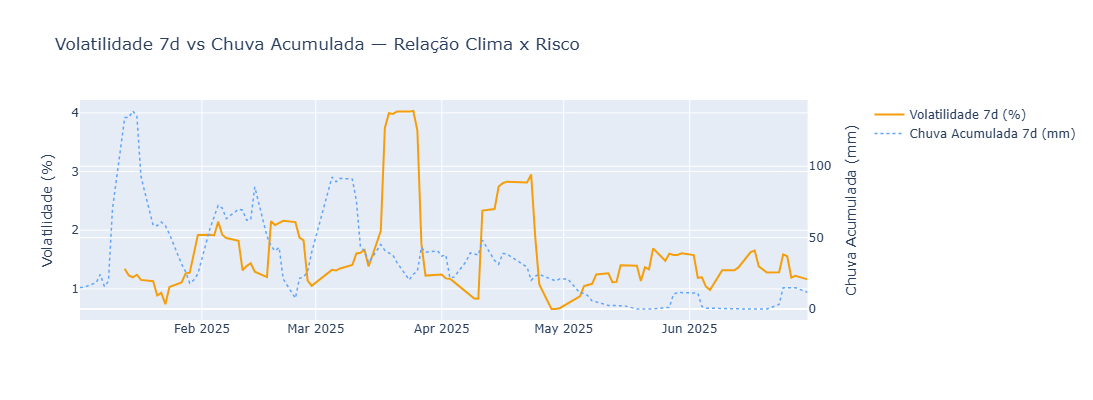

In [15]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=df['data'], y=df['volatilidade_7d'],
                         name='Volatilidade 7d (%)',
                         line=dict(color='#f59e0b', width=2)), secondary_y=False)
fig.add_trace(go.Scatter(x=df['data'], y=df['chuva_acumulada_7d'],
                         name='Chuva Acumulada 7d (mm)',
                         line=dict(color='#60a5fa', width=1.5, dash='dot')), secondary_y=True)
fig.update_layout(title='Volatilidade 7d vs Chuva Acumulada — Relação Clima x Risco',
                  height=400, hovermode='x unified')
fig.update_yaxes(title_text='Volatilidade (%)', secondary_y=False)
fig.update_yaxes(title_text='Chuva Acumulada (mm)', secondary_y=True)
fig

### 6.11 Resumo Mensal — Preço e Precipitação

**Responde:** períodos de plantio/colheita impactam o preço? Janeiro e Fevereiro correspondem à colheita de soja em Mato Grosso — o preço estava em baixa. Abril, já no período seco, registrou o pico do semestre.

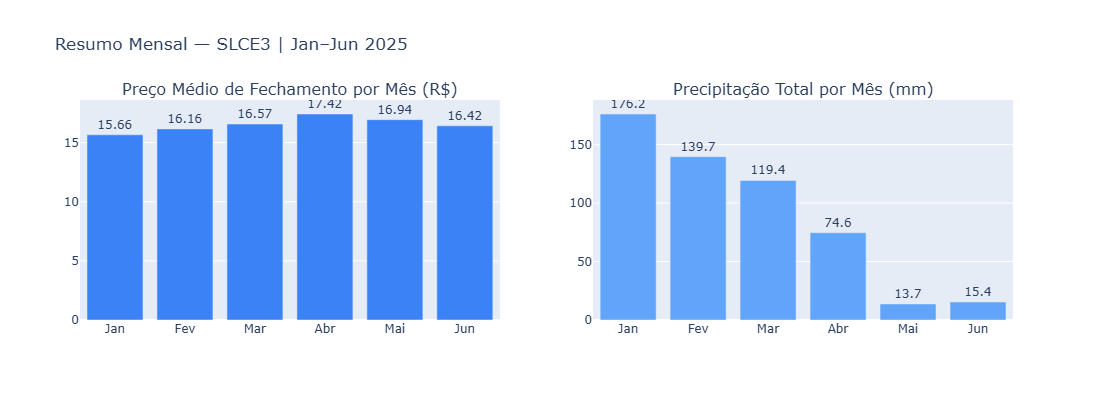

In [16]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Preço Médio de Fechamento por Mês (R$)',
                                    'Precipitação Total por Mês (mm)'))
fig.add_trace(go.Bar(x=mensal['nome_mes'], y=mensal['preco_medio'].round(2),
                     marker_color='#3b82f6',
                     text=mensal['preco_medio'].round(2),
                     textposition='outside'), row=1, col=1)
fig.add_trace(go.Bar(x=mensal['nome_mes'], y=mensal['precip_total'].round(1),
                     marker_color='#60a5fa',
                     text=mensal['precip_total'].round(1),
                     textposition='outside'), row=1, col=2)
fig.update_layout(height=400, showlegend=False,
                  title='Resumo Mensal — SLCE3 | Jan–Jun 2025')
fig

## 7. Conclusões

Respostas às perguntas de negócio definidas na documentação do projeto, geradas automaticamente a partir dos dados analisados.

In [17]:
topo       = df_corr.iloc[0]
r_chuva    = df_corr[df_corr['Variável Climática'] == 'Precipitação Diária']['r (vs preço)'].values[0]
r_lag      = df_corr[df_corr['Variável Climática'] == 'Precipitação Lag 7d']['r (vs preço)'].values[0]
dd_junho   = mensal[mensal['mes'] == 6]['drawdown_medio'].values[0]

conclusoes = {
    'Variável com maior correlação':  f"{topo['Variável Climática']} (r = {topo['r (vs preço)']}) — {topo['Força']} {topo['Direção']}",
    'Impacto da chuva no preço':      f"r = {r_chuva} (Fraca Negativa) — chuvas intensas coincidem com leve queda no preço",
    'Efeito defasado (lag 7d)':       f"r = {r_lag} (Desprezível) — o impacto climático é imediato, não defasado",
    'Seca prolongada e drawdown':     f"Mai–Jun com precipitação quase zero; drawdown médio em Junho = {dd_junho:.1f}% (pior do semestre)",
    'Variação total do ativo':        f"{kpis['Variação Total (%)']:+.2f}%",
    'Drawdown máximo':                f"{kpis['Drawdown Máximo (%)']}%",
    'Volatilidade diária':            f"{kpis['Volatilidade Diária (%)']}%",
}

pd.DataFrame(conclusoes.items(), columns=['Pergunta de Negócio', 'Resposta'])

,Pergunta de Negócio,Resposta
0,Variável com maior correlação,Temperatura Máxima (r = 0.3499) — Moderada Pos...
1,Impacto da chuva no preço,r = -0.2343 (Fraca Negativa) — chuvas intensas...
2,Efeito defasado (lag 7d),r = -0.0529 (Desprezível) — o impacto climátic...
3,Seca prolongada e drawdown,Mai–Jun com precipitação quase zero; drawdown ...
4,Variação total do ativo,+3.18%
5,Drawdown máximo,-14.55%
6,Volatilidade diária,1.69%
